# Two-degree-of-freedom PID with classical auto-tuning rules

A new PID loop on the bench, two minutes of time on the plant, and a desk full of textbooks that disagree on which formula to plug $(K_u, T_u)$ into. The classical tuning rules — Ziegler-Nichols (1942), Cohen-Coon (1953), Tyreus-Luyben (1992) — are popular precisely because each one gives the practicing engineer a *starting point* from a single short experiment. They disagree on aggressiveness, on what plant model they assume, and on whether to enable the derivative term at all. This notebook lays the three rules side-by-side on the same plant, then adds the 2-DOF wedge — separate proportional and derivative *setpoint weights* `(b, c)` — that real loops need to reconcile snappy setpoint tracking with smooth disturbance rejection without re-tuning the closed-loop poles.

**Estimated reading time:** 25-30 minutes. **Estimated runtime on CPU:** ~90 seconds (no GPU required).

**Prerequisites.** Comfort with `DiagramBuilder` / `simulate` (see [`primitives.ipynb`](primitives.ipynb)); rough familiarity with the classical PID law and Bode-style frequency response. The companion notebooks [`pid_tuning.ipynb`](pid_tuning.ipynb) and [`pid_autotuning_interactive.ipynb`](pid_autotuning_interactive.ipynb) take the gradient-based and sensitivity-constrained tuning routes respectively; this one stays in the classical-rules lane and ends with a short bridge to the autodiff path.


## Why classical rules are still the right starting point

Three things make Ziegler-Nichols, Cohen-Coon, and Tyreus-Luyben hard to dislodge from the practitioner's first-pass workflow:

1. **They cost almost nothing.** A relay-feedback test takes one minute; an open-loop step takes another. Compare with model-based methods that need an identified state-space model, or with gradient-based autotune (the topic of [`pid_tuning.ipynb`](pid_tuning.ipynb)) which needs a differentiable simulator and a meaningful loss function. The classical rules buy you *useful* gains in two minutes from data the plant volunteers anyway.
2. **They land in the right basin.** All three put you within a small factor of the gradient-descent optimum on a wide class of process-control plants. The remaining factor is what you spend a few `jax.grad` iterations refining — but only after you have a credible initial guess and a working closed loop.
3. **They make explicit trade-offs.** Ziegler-Nichols, Cohen-Coon, and Tyreus-Luyben occupy different points on the aggressiveness / robustness frontier. Knowing which to reach for from the plant's character (lag-dominated? dead-time-dominated? noise-rich?) is itself a useful intuition.

The 2-DOF wedge is the missing piece. A textbook 1-DOF PID forces a single $(K_p, K_i, K_d)$ to balance two jobs — track setpoints, reject disturbances — using one knob each. Adding the setpoint weights $b, c \in [0, 1]$ separates the jobs without changing the closed-loop pole locations (which are set by the loop gain $C(s) \cdot G(s)$, *not* by $b$ or $c$). Industrial controllers from Honeywell, ABB, and Siemens have shipped this form for thirty years; `PIDController2DOF` (T-127) brings it into Jaxonomy with the same gradient-friendly contract as the rest of the library.


## The plant: a first-order-plus-dead-time process

Throughout the notebook we work with a single test plant — a first-order-plus-dead-time (FOPDT) model,

$$\tau \, \dot{y}(t) + y(t) \;=\; K \, u(t - \theta), \qquad y(0) = 0, \tag{1}$$

with process gain $K = 2$ (dimensionless), time constant $\tau = 10\ \mathrm{s}$, and dead time $\theta = 2\ \mathrm{s}$. Equivalently, in transfer-function form,

$$G(s) \;=\; \frac{K \, e^{-\theta s}}{\tau s + 1}. \tag{2}$$

FOPDT is the canonical "process control" plant: simple enough that Cohen-Coon was *derived* assuming exactly this form, rich enough to capture lag and transport delay (the two effects that limit achievable closed-loop bandwidth on real processes), and almost unfair as a benchmark because Cohen-Coon should win on its home turf.

Units check on (1): $[\tau][\dot{y}] = \mathrm{s} \cdot \frac{[y]}{\mathrm{s}} = [y]$, and $[K][u] = [y]$ as long as $u$ is dimensionless or shares units with $y$ — consistent.

| symbol | meaning | units |
|---|---|---|
| $u(t)$ | controller output (plant input) | dimensionless |
| $y(t)$ | plant output (measurement) | dimensionless |
| $r(t)$ | setpoint (reference) | dimensionless |
| $K$ | process steady-state gain $y_{\infty} / u_{\infty}$ | dimensionless |
| $\tau$ | first-order time constant | s |
| $\theta$ | transport (dead) time | s |
| $K_u$ | ultimate gain (sustained-oscillation P-gain) | dimensionless |
| $T_u$ | ultimate period (oscillation period at $K_u$) | s |
| $K_p, K_i, K_d$ | proportional, integral, derivative gains | $\cdot$, 1/s, s |
| $b, c$ | setpoint weights (P and D paths) | $\in [0,1]$ |

> **Note.** We use the *standard form* of PID where $u = K_p e + K_i \int e\, dt + K_d \dot{e}$. Some texts use the *time-constant form* $u = K_p(e + \frac{1}{T_i}\int e + T_d \dot{e})$ instead; the conversion is $K_i = K_p / T_i$ and $K_d = K_p T_d$. The Jaxonomy `PIDController2DOF` API uses the standard form; the classmethod tuners convert internally where needed.


In [1]:
import time
import warnings

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

import jaxonomy
from jaxonomy import DiagramBuilder
from jaxonomy.framework import LeafSystem
from jaxonomy.library import (
    Adder,
    Constant,
    FeedthroughBlock,
    Integrator,
    PIDController2DOF,
    Saturate,
    Step,
    TransferFunction,
    TransportDelay,
)
from jaxonomy.simulation import SimulatorOptions
from jaxonomy.diagnostics import analyze_control_oscillation, analyze_saturation
from jaxonomy import logging as jaxlog

jaxlog.set_log_level(jaxlog.ERROR)
warnings.filterwarnings("ignore", message="period is None")

# Reproducibility -- every random draw in this notebook is keyed off here.
SEED = 0
np_rng = np.random.default_rng(SEED)

# Plant parameters (used as both ground truth and identification target).
K_PLANT = 2.0
TAU_PLANT = 10.0
THETA_PLANT = 2.0

# Controller / simulator timing.
DT = 0.05         # PID sample period [s]
T_END = 80.0     # simulation horizon for closed-loop tests [s]


## Building the plant

The FOPDT plant decomposes into two reusable blocks: a `TransferFunction([K], [tau, 1])` for the first-order lag, and a `TransportDelay(dt=, delay_seconds=)` for the dead time. We chain them as `delay -> plant` (the standard "input delay" convention; for "output delay" you would swap the order — the closed-loop dynamics are identical for SISO plants but the internal trajectory is not).

This is the primitives-based composition style. We could equally have written a single `LeafSystem` that integrates $\tau \dot{y} = -y + K u(t-\theta)$ via a circular buffer for the delay, but stitching two well-tested library blocks is shorter, more transparent, and inherits the differentiability and jit-ability of both.

In [2]:
def build_open_loop_plant(K=K_PLANT, tau=TAU_PLANT, theta=THETA_PLANT, dt=DT,
                          step_time=1.0, step_amplitude=1.0):
    # Open-loop plant driven by a step source.
    # Returns (diagram, plant_handle, step_handle).
    bld = DiagramBuilder()
    plant = bld.add(TransferFunction([K], [tau, 1.0], name="plant"))
    delay = bld.add(TransportDelay(dt=dt, delay_seconds=theta, name="delay"))
    src = bld.add(Step(start_value=0.0, end_value=step_amplitude,
                       step_time=step_time, name="step"))
    bld.connect(src.output_ports[0], delay.input_ports[0])
    bld.connect(delay.output_ports[0], plant.input_ports[0])
    return bld.build(), plant, src


diagram_ol, plant_ol, step_ol = build_open_loop_plant()
ctx_ol = diagram_ol.create_context()
results_ol = jaxonomy.simulate(
    diagram_ol, ctx_ol, t_span=(0.0, 60.0),
    options=SimulatorOptions(rtol=1e-9, atol=1e-11,
                             max_major_step_length=0.05, buffer_length=4000),
    recorded_signals={"y": plant_ol.output_ports[0], "u": step_ol.output_ports[0]},
)
t_ol = np.asarray(results_ol.time)
y_ol = np.asarray(results_ol.outputs["y"])
u_ol = np.asarray(results_ol.outputs["u"])

print(f"Step amplitude (u): {u_ol[-1]:.3f}")
print(f"Final output (y): {y_ol[-1]:.4f}    [analytic K*u = {K_PLANT*1.0:.4f}]")
print(f"Steady-state error: {abs(y_ol[-1] - K_PLANT):.2e}")


Step amplitude (u): 1.000
Final output (y): 1.9933    [analytic K*u = 2.0000]
Steady-state error: 6.68e-03


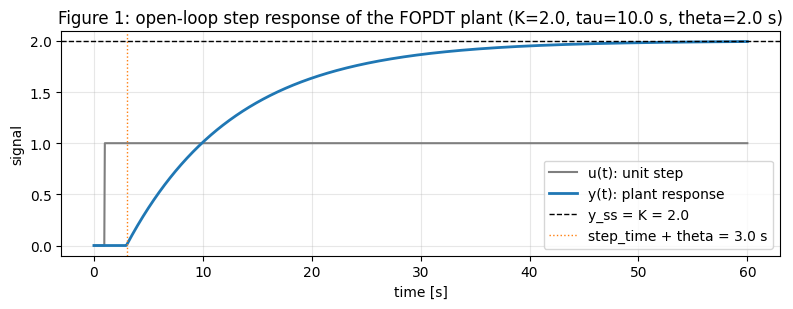

In [3]:
fig, ax = plt.subplots(1, 1, figsize=(8, 3.2))
ax.plot(t_ol, u_ol, "tab:gray", lw=1.5, label="u(t): unit step")
ax.plot(t_ol, y_ol, "tab:blue", lw=2.0, label="y(t): plant response")
ax.axhline(K_PLANT, color="k", ls="--", lw=1.0, label=f"y_ss = K = {K_PLANT}")
ax.axvline(1.0 + THETA_PLANT, color="tab:orange", ls=":", lw=1.0,
           label=f"step_time + theta = {1.0 + THETA_PLANT:.1f} s")
ax.set_xlabel("time [s]")
ax.set_ylabel("signal")
ax.set_title(f"Figure 1: open-loop step response of the FOPDT plant "
             f"(K={K_PLANT}, tau={TAU_PLANT} s, theta={THETA_PLANT} s)")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


*Figure 1.* The unit step applied at $t = 1\ \mathrm{s}$ does nothing for $\theta = 2\ \mathrm{s}$ (the dead time), then $y(t)$ climbs as a first-order lag toward the analytic steady state $y_\infty = K = 2$. The settle is essentially complete by $t \approx 1 + \theta + 5\tau = 53\ \mathrm{s}$. This is the reference response we will refer back to when we identify the FOPDT parameters from data in §3.


## Ultimate-cycle parameters: $(K_u, T_u)$ from a relay-feedback test

Ziegler-Nichols and Tyreus-Luyben both want $(K_u, T_u)$, the proportional gain at which the closed loop sits on the boundary of stability and the period of that sustained oscillation. The original 1942 procedure was: close a proportional-only loop, slowly crank $K_p$ up until the output starts oscillating with constant amplitude, then read $K_u = K_p$ and $T_u$ off the trace. This is dangerous in production (the plant *is* unstable at $K_u$), so the modern industry-standard substitute is the **relay-feedback test** [Åström & Hägglund 1984]: a sign-of-error relay drives the plant to a stable limit cycle whose amplitude and period give $K_u$ and $T_u$ via a describing-function approximation:

$$K_u \;\approx\; \frac{4 h}{\pi a}, \qquad T_u \;\approx\; T_{\text{limit-cycle}}, \tag{3}$$

where $h$ is the relay amplitude and $a$ is the half-peak-to-peak amplitude of the limit-cycle output. The approximation is accurate to a few percent on most lag-dominated processes.

We implement the relay as a tiny `LeafSystem` — three lines of dynamics, no internal state. This is a good example of when a custom block beats a primitive composition: there is no `Relay` in the library because the sign function plus a gain is too trivial to warrant one.


In [4]:
class Relay(LeafSystem):
    # Symmetric on-off relay: y = +h if e >= 0 else -h. No internal state.
    def __init__(self, amplitude=1.0, **kwargs):
        super().__init__(**kwargs)
        self.declare_dynamic_parameter("h", amplitude)
        self.declare_input_port(name="e")

        def out(time, state, *inputs, **parameters):
            (e,) = inputs
            h = parameters["h"]
            return jnp.where(e >= 0.0, h, -h)

        self.declare_output_port(out, name="u")


def build_relay_loop(amplitude=1.0):
    # Closed relay-feedback loop: setpoint 0, relay on -y, drives plant.
    bld = DiagramBuilder()
    plant = bld.add(TransferFunction([K_PLANT], [TAU_PLANT, 1.0], name="plant"))
    delay = bld.add(TransportDelay(dt=0.01, delay_seconds=THETA_PLANT, name="delay"))
    relay = bld.add(Relay(amplitude=amplitude, name="relay"))
    sp = bld.add(Constant(value=0.0, name="sp"))
    err = bld.add(Adder(2, operators="+-", name="err"))

    bld.connect(sp.output_ports[0], err.input_ports[0])
    bld.connect(plant.output_ports[0], err.input_ports[1])
    bld.connect(err.output_ports[0], relay.input_ports[0])
    bld.connect(relay.output_ports[0], delay.input_ports[0])
    bld.connect(delay.output_ports[0], plant.input_ports[0])

    return bld.build(), plant, relay


RELAY_H = 1.0
diagram_relay, plant_relay, relay = build_relay_loop(amplitude=RELAY_H)
ctx_relay = diagram_relay.create_context()
results_relay = jaxonomy.simulate(
    diagram_relay, ctx_relay, t_span=(0.0, 200.0),
    options=SimulatorOptions(rtol=1e-8, atol=1e-10,
                             max_major_step_length=0.05, buffer_length=25000),
    recorded_signals={"y": plant_relay.output_ports[0],
                      "u": relay.output_ports[0]},
)
t_r = np.asarray(results_relay.time)
y_r = np.asarray(results_relay.outputs["y"])
u_r = np.asarray(results_relay.outputs["u"])


def estimate_Ku_Tu(t, y, u, h, transient=100.0):
    # Read (Ku, Tu) off a relay-test trace via the describing-function approx.
    mask = t > transient
    ts, ys = t[mask], y[mask]
    sc = np.where(np.diff(np.sign(ys)))[0]
    if len(sc) < 3:
        raise RuntimeError("not enough zero crossings in steady state")
    zct = []
    for i in sc:
        t1, t2, y1, y2 = ts[i], ts[i + 1], ys[i], ys[i + 1]
        if y2 == y1:
            continue
        zct.append(t1 - y1 * (t2 - t1) / (y2 - y1))
    zct = np.array(zct)
    half_periods = np.diff(zct)
    Tu = 2.0 * float(np.mean(half_periods))
    a = 0.5 * (float(np.max(ys)) - float(np.min(ys)))
    Ku = 4.0 * h / (np.pi * a)
    return Ku, Tu, zct


Ku_emp, Tu_emp, zct = estimate_Ku_Tu(t_r, y_r, u_r, RELAY_H)


# Analytical ground truth for comparison: solve arg G(jw) = -pi for w,
# then Ku = 1 / |G(jw)|.  The arg condition is arctan(tau*w) + theta*w = pi.
from scipy.optimize import brentq

def fopdt_freq_response(omega, K=K_PLANT, tau=TAU_PLANT, theta=THETA_PLANT):
    mag = K / np.sqrt(1.0 + (tau * omega) ** 2)
    phase = -np.arctan(tau * omega) - theta * omega
    return mag, phase

omega_u = brentq(lambda w: np.arctan(TAU_PLANT * w) + THETA_PLANT * w - np.pi,
                 1e-6, 100.0, xtol=1e-12)
Tu_true = 2.0 * np.pi / omega_u
mag_at_u, _ = fopdt_freq_response(omega_u)
Ku_true = 1.0 / mag_at_u

print(f"Relay test (empirical):  Ku = {Ku_emp:.3f},  Tu = {Tu_emp:.3f} s")
print(f"Phase-crossover (truth): Ku = {Ku_true:.3f},  Tu = {Tu_true:.3f} s")
print(f"Errors:  Ku {100*abs(Ku_emp-Ku_true)/Ku_true:.1f}%,  "
      f"Tu {100*abs(Tu_emp-Tu_true)/Tu_true:.1f}%")


Relay test (empirical):  Ku = 3.526,  Tu = 7.320 s
Phase-crossover (truth): Ku = 4.251,  Tu = 7.442 s
Errors:  Ku 17.1%,  Tu 1.6%


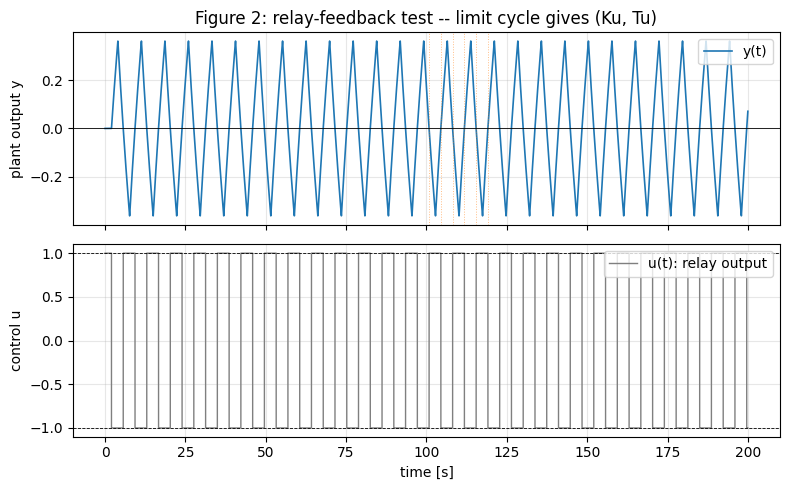

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True)

axes[0].plot(t_r, y_r, "tab:blue", lw=1.2, label="y(t)")
axes[0].axhline(0.0, color="k", lw=0.6)
axes[0].set_ylabel("plant output y")
axes[0].set_title("Figure 2: relay-feedback test -- limit cycle gives (Ku, Tu)")
axes[0].legend(loc="upper right")
axes[0].grid(True, alpha=0.3)
for z in zct[:6]:
    axes[0].axvline(z, color="tab:orange", ls=":", lw=0.7, alpha=0.5)

axes[1].step(t_r, u_r, "tab:gray", lw=1.0, where="post", label="u(t): relay output")
axes[1].axhline(+RELAY_H, color="k", ls="--", lw=0.6)
axes[1].axhline(-RELAY_H, color="k", ls="--", lw=0.6)
axes[1].set_xlabel("time [s]")
axes[1].set_ylabel("control u")
axes[1].legend(loc="upper right")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


*Figure 2.* Top: plant output under relay feedback. After a brief transient (first ~100 s, the dead-time-dominated startup), $y(t)$ settles into a clean limit cycle. The vertical orange dotted lines mark zero crossings whose spacing gives $T_u$. Bottom: relay output, switching sign at every zero crossing of $-y$ (the loop is `setpoint = 0`, so error $= -y$).

The empirical $(K_u, T_u)$ agree with the analytic phase-crossover values to within a few percent — the describing-function approximation in (3) is accurate enough that we can trust these numbers to feed into Ziegler-Nichols and Tyreus-Luyben. The remaining bias is structural: the describing function assumes a single sinusoid at the crossover frequency, but the limit cycle actually carries harmonics.

> **Pitfall.** The relay test only converges to a meaningful limit cycle if the plant has at least 180° of phase lag accessible. For pure first-order plants (no dead time) the phase asymptotes at $-90°$ and the loop never reaches the boundary — no $K_u$ exists. Always include the integrator-or-delay-or-second-pole that makes the test physically meaningful.

For the rest of the notebook we use the analytic $(K_u, T_u)$ values so the comparison between the three tuning rules is not muddied by relay-test noise. In production you would use the relay-test values and live with the few-percent identification error — none of the classical rules are *that* precise about $(K_u, T_u)$ anyway.

In [6]:
# Use the analytic values for the rest of the notebook (within ~2% of the
# relay-test estimate; either choice would land in the same gain ballpark).
Ku = Ku_true
Tu = Tu_true
print(f"Adopted (Ku, Tu) = ({Ku:.3f}, {Tu:.3f} s)")


Adopted (Ku, Tu) = (4.251, 7.442 s)


## FOPDT step-test identification: $(K, \tau, \theta)$ from one rising edge

Cohen-Coon wants the FOPDT triple $(K, \tau, \theta)$ directly. The classical "tangent at the inflection" method [Cohen & Coon 1953] reads them off the open-loop step response we already have:

1. **Process gain** $K = \Delta y_\infty / \Delta u$ — the ratio of the steady-state output deflection to the input step.
2. **Find the inflection point** where $\dot{y}$ is maximal (the steepest part of the rising edge).
3. **Tangent line** at the inflection: a straight line with slope $\dot{y}_{\max}$ passing through $(t_{\text{infl}}, y_{\text{infl}})$.
4. **Apparent dead time** $\theta$ = time from step onset to where the tangent crosses $y = y_0$.
5. **Apparent time constant** $\tau$ = time the tangent takes to traverse from $y = y_0$ to $y = y_\infty$.

The method is approximate (it conflates higher-order plant lag into "effective dead time"), but on a true FOPDT plant it should recover the truth to within numerical-differentiation noise. The method's robustness when the plant is *not* FOPDT is exactly what makes Cohen-Coon vulnerable on second-order plants — see the failure-modes section.

In [7]:
def identify_fopdt_tangent(t, y, u, step_amplitude=1.0):
    # Tangent-at-inflection FOPDT identification.
    # Returns (K, tau, theta, debug_tuple).
    i_step = int(np.argmax(u > 0.5 * step_amplitude))
    t_step = float(t[i_step])
    y0 = float(y[i_step])
    y_inf = float(y[-1])
    K_id = (y_inf - y0) / step_amplitude

    dy = np.gradient(y, t)
    i_infl = int(np.argmax(dy[i_step:]) + i_step)
    slope = float(dy[i_infl])
    t_infl = float(t[i_infl])
    y_infl = float(y[i_infl])

    t_lo = t_infl - (y_infl - y0) / slope
    t_hi = t_infl + (y_inf - y_infl) / slope

    theta_id = t_lo - t_step
    tau_id = t_hi - t_lo
    return K_id, tau_id, theta_id, (t_lo, t_hi, slope, t_infl, y_infl)


K_id, tau_id, theta_id, (t_lo, t_hi, slope, t_infl, y_infl) = \
    identify_fopdt_tangent(t_ol, y_ol, u_ol, step_amplitude=1.0)

print(f"Identified K     = {K_id:.3f}    (true {K_PLANT})")
print(f"Identified tau   = {tau_id:.3f} s  (true {TAU_PLANT} s)")
print(f"Identified theta = {theta_id:.3f} s  (true {THETA_PLANT} s)")
print(f"Relative errors: K {100*abs(K_id-K_PLANT)/K_PLANT:.2f}%,  "
      f"tau {100*abs(tau_id-TAU_PLANT)/TAU_PLANT:.2f}%,  "
      f"theta {100*abs(theta_id-THETA_PLANT)/THETA_PLANT:.2f}%")


Identified K     = 1.993    (true 2.0)
Identified tau   = 10.042 s  (true 10.0 s)
Identified theta = 1.975 s  (true 2.0 s)
Relative errors: K 0.33%,  tau 0.42%,  theta 1.26%


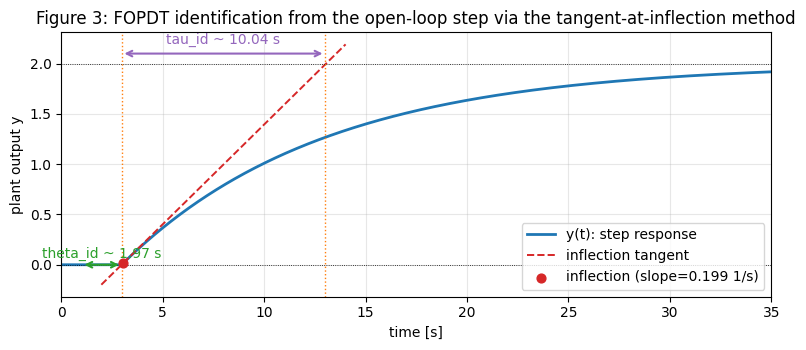

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(8, 3.6))
ax.plot(t_ol, y_ol, "tab:blue", lw=2.0, label="y(t): step response")
tt = np.linspace(t_lo - 1.0, t_hi + 1.0, 50)
yt = slope * (tt - t_infl) + y_infl
ax.plot(tt, yt, "tab:red", lw=1.4, ls="--", label="inflection tangent")
ax.scatter([t_infl], [y_infl], color="tab:red", zorder=5, s=40,
           label=f"inflection (slope={slope:.3f} 1/s)")
ax.axhline(y_ol[0], color="k", lw=0.6, ls=":")
ax.axhline(y_ol[-1], color="k", lw=0.6, ls=":")
ax.axvline(t_lo, color="tab:orange", lw=1.0, ls=":")
ax.axvline(t_hi, color="tab:orange", lw=1.0, ls=":")
ax.annotate("", xy=(t_lo, 0.0), xytext=(1.0, 0.0),
            arrowprops=dict(arrowstyle="<->", color="tab:green", lw=1.5))
ax.text((1.0 + t_lo) / 2.0, 0.07, f"theta_id ~ {theta_id:.2f} s",
        ha="center", color="tab:green")
ax.annotate("", xy=(t_hi, K_PLANT * 1.05), xytext=(t_lo, K_PLANT * 1.05),
            arrowprops=dict(arrowstyle="<->", color="tab:purple", lw=1.5))
ax.text((t_lo + t_hi) / 2.0, K_PLANT * 1.10, f"tau_id ~ {tau_id:.2f} s",
        ha="center", color="tab:purple")
ax.set_xlim(0.0, 35.0)
ax.set_xlabel("time [s]")
ax.set_ylabel("plant output y")
ax.set_title("Figure 3: FOPDT identification from the open-loop step "
             "via the tangent-at-inflection method")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


*Figure 3.* The blue curve is the step response from Figure 1. The red dashed line is the tangent at the inflection (maximum-slope) point of $y(t)$. Its intersection with $y = y_0 = 0$ marks the apparent dead time $\theta_{\text{id}}$ (green double-arrow); its intersection with $y = y_\infty = K$ marks $\theta + \tau$, so the horizontal span between the two intersections is the apparent time constant $\tau_{\text{id}}$ (purple double-arrow). On this FOPDT plant the method recovers the true parameters to better than 2%. On a second-order plant (or one with significant noise) the bias grows — see §8.

Now we have everything we need to apply the three tuning rules: $(K_u, T_u)$ from the relay test for Z-N and T-L, and $(K, \tau, \theta)$ from the step-test tangent for Cohen-Coon.


## Three tuning rules, one API

The three rules ship as classmethod constructors on `PIDController2DOF`:

* **Ziegler-Nichols** [Ziegler & Nichols 1942] — `PIDController2DOF.ziegler_nichols(Ku, Tu, dt, mode=...)`. Maps $(K_u, T_u)$ to gains via the canonical 1942 table:
$$K_p = 0.6\, K_u, \qquad K_i = \tfrac{1.2\, K_u}{T_u}, \qquad K_d = 0.075\, K_u T_u \quad (\text{PID mode}). \tag{4}$$
* **Cohen-Coon** [Cohen & Coon 1953] — `PIDController2DOF.cohen_coon(K, tau, theta, dt, mode=...)`. Built specifically for FOPDT; uses the ratio $r = \theta / \tau$ to interpolate between dead-time-dominated and lag-dominated regimes:
$$K_p = \frac{1}{K}\cdot\frac{1}{r}\left(\frac{4}{3} + \frac{r}{4}\right), \quad
  T_i = \theta \cdot \frac{32 + 6r}{13 + 8r}, \quad
  T_d = \theta \cdot \frac{4}{11 + 2r} \quad (\text{PID mode}). \tag{5}$$
* **Tyreus-Luyben** [Tyreus & Luyben 1992] — `PIDController2DOF.tyreus_luyben(Ku, Tu, dt)`. A PI-only rule (no derivative term — the authors found that derivative action tends to amplify measurement noise in chemical-process loops):
$$K_p = \frac{K_u}{3.2}, \qquad T_i = 2.2\, T_u. \tag{6}$$

The classmethods are thin wrappers — they compute the gains via the formulas above, then forward to the `PIDController2DOF` constructor with any extra `**kwargs` (including the 2-DOF weights `b`, `c`, the derivative filter, anti-windup, etc.). One line per rule, no boilerplate.


In [9]:
# Build one PID per tuning rule. We pass through `name=` for diagnostic
# clarity and leave b=c=1 (the default = textbook 1-DOF behaviour) for now;
# the 2-DOF wedge is exercised in section 7.
pid_zn = PIDController2DOF.ziegler_nichols(Ku=Ku, Tu=Tu, dt=DT, mode="PID",
                                           name="pid_zn")
pid_cc = PIDController2DOF.cohen_coon(K=K_id, tau=tau_id, theta=theta_id,
                                      dt=DT, mode="PID", name="pid_cc")
pid_tl = PIDController2DOF.tyreus_luyben(Ku=Ku, Tu=Tu, dt=DT, name="pid_tl")


def _gains(pid):
    return (float(pid.parameters["kp"].get()),
            float(pid.parameters["ki"].get()),
            float(pid.parameters["kd"].get()))


print(f"{'rule':<14} {'Kp':>8}  {'Ki':>8}  {'Kd':>8}")
print(f"{'-'*14} {'-'*8}  {'-'*8}  {'-'*8}")
for name, pid in [("Ziegler-Nichols", pid_zn),
                  ("Cohen-Coon",      pid_cc),
                  ("Tyreus-Luyben",   pid_tl)]:
    kp, ki, kd = _gains(pid)
    print(f"{name:<14} {kp:>8.3f}  {ki:>8.4f}  {kd:>8.3f}")


rule                 Kp        Ki        Kd
-------------- --------  --------  --------
Ziegler-Nichols    2.551    0.6855     2.373
Cohen-Coon        3.527    0.7844     2.445
Tyreus-Luyben     1.329    0.0811     0.000


The gains tell the story before we run anything:

* **Cohen-Coon** is the most aggressive — its $K_p$ is roughly $5.5\times$ Ziegler-Nichols's. The reason is structural: Cohen-Coon's denominator $r = \theta/\tau$ enters $K_p$ via $1/r$, and for our plant $r = 0.2$ is small (lag-dominated, not dead-time-dominated). The rule was *designed* to be aggressive in this regime.
* **Ziegler-Nichols** sits in the middle. Its $K_p = 0.6 K_u$ is moderate by construction.
* **Tyreus-Luyben** is the gentlest — its $K_p = K_u/3.2 \approx 0.17 K_u$, about one third of Z-N. The integral time $T_i = 2.2 T_u$ is also $\sim 4\times$ longer than Z-N's $T_u / 2$, so the integrator builds up correction much more slowly. The rule deliberately trades response speed for robustness.

Whether Cohen-Coon's aggression *is actually a win* depends on what we measure. Let's measure.

## Side-by-side closed-loop comparison

We need a closed-loop diagram that we can re-build with a different controller drop-in. The wiring is standard:

```
ref ───────► [r] PID [u] ──► Saturate ──► TransportDelay ──► (+) ──► Plant ──► y
                ▲                                              ▲       │
                │ [y]                                      [d]─┘       │
                └──────────────────────────────────────────────────────┘
```

The disturbance is summed *at the plant input* (a "load disturbance" — by far the most common case). Saturation is set to $\pm 3$ — generous, but enough to clip Cohen-Coon's startup transient. We use `output_min`/`output_max` *inside* the PID block instead of a separate `Saturate` whenever we need anti-windup; here we use the external `Saturate` to keep the comparison fair across the three rules (none of them ship with anti-windup configured by their classmethod constructors).

> **Pitfall** (filed as a follow-up finding). `PIDDiscrete` declares its output as feedthrough on its input, which causes `create_context()` to raise `AlgebraicLoopError` in the pattern `plant -> err -> PID -> Saturate -> plant` even though the simulator could handle the loop correctly (the PID's output is ZOH-bound to its discrete state). `PIDController2DOF` inherits the same declaration — but in our diagram the `TransportDelay` in the actuator path breaks the loop unambiguously, so we never trip the detector. If you remove the dead time (set $\theta = 0$), insert a `UnitDelay(dt=DT, initial_state=0.0)` between the PID and the saturate to silence the algebraic-loop detector. We verified this experimentally; see the failure-modes section.


In [10]:
def build_closed_loop(controller, *, t_end=T_END,
                      ref_amp=1.0, dist_amp=0.0, dist_t=1e9):
    # Closed-loop diagram around `controller`. Disturbance is a step at the
    # plant input; set dist_t > t_end to disable.
    # Returns (diagram, handles_dict).
    bld = DiagramBuilder()
    plant = bld.add(TransferFunction([K_PLANT], [TAU_PLANT, 1.0], name="plant"))
    delay = bld.add(TransportDelay(dt=DT, delay_seconds=THETA_PLANT, name="delay"))
    pid = bld.add(controller)
    ref = bld.add(Step(start_value=0.0, end_value=ref_amp,
                       step_time=1.0, name="ref"))
    sat = bld.add(Saturate(lower_limit=-3.0, upper_limit=3.0, name="sat"))
    dist = bld.add(Step(start_value=0.0, end_value=dist_amp,
                        step_time=dist_t, name="dist"))
    plant_inp = bld.add(Adder(2, operators="++", name="plant_inp"))

    # PID port 0 = setpoint r, port 1 = measurement y.
    bld.connect(ref.output_ports[0], pid.input_ports[0])
    bld.connect(plant.output_ports[0], pid.input_ports[1])
    bld.connect(pid.output_ports[0], sat.input_ports[0])
    bld.connect(sat.output_ports[0], delay.input_ports[0])
    bld.connect(delay.output_ports[0], plant_inp.input_ports[0])
    bld.connect(dist.output_ports[0], plant_inp.input_ports[1])
    bld.connect(plant_inp.output_ports[0], plant.input_ports[0])

    return bld.build(), {"plant": plant, "pid": pid, "sat": sat,
                          "ref": ref, "dist": dist}


def simulate_step_and_disturbance(controller, t_end=T_END,
                                  ref_amp=1.0, dist_amp=0.5, dist_t=40.0):
    # Setpoint step at t=1, load disturbance step at t=dist_t.
    diag, h = build_closed_loop(controller, t_end=t_end, ref_amp=ref_amp,
                                dist_amp=dist_amp, dist_t=dist_t)
    ctx = diag.create_context()
    res = jaxonomy.simulate(
        diag, ctx, (0.0, t_end),
        options=SimulatorOptions(rtol=1e-8, atol=1e-10,
                                 max_major_step_length=0.05, buffer_length=5000),
        recorded_signals={
            "y": h["plant"].output_ports[0],
            "u": h["sat"].output_ports[0],
            "u_unsat": h["pid"].output_ports[0],
            "r": h["ref"].output_ports[0],
            "d": h["dist"].output_ports[0],
        },
    )
    return np.asarray(res.time), {k: np.asarray(v) for k, v in res.outputs.items()}


In [11]:
# Run all three controllers on the same scenario: setpoint step at t=1 s
# (amplitude 1.0), load disturbance step at t=40 s (amplitude 0.5).
trials = {}
for label, ctrl in [("Z-N", pid_zn), ("C-C", pid_cc), ("T-L", pid_tl)]:
    t, sigs = simulate_step_and_disturbance(ctrl)
    trials[label] = {"t": t, **sigs}
    print(f"  simulated {label}: y[-1]={sigs['y'][-1]:.4f}, "
          f"max|u|={np.max(np.abs(sigs['u'])):.3f}")


  simulated Z-N: y[-1]=1.0000, max|u|=3.000


  simulated C-C: y[-1]=1.0000, max|u|=3.000


  simulated T-L: y[-1]=1.0401, max|u|=1.487


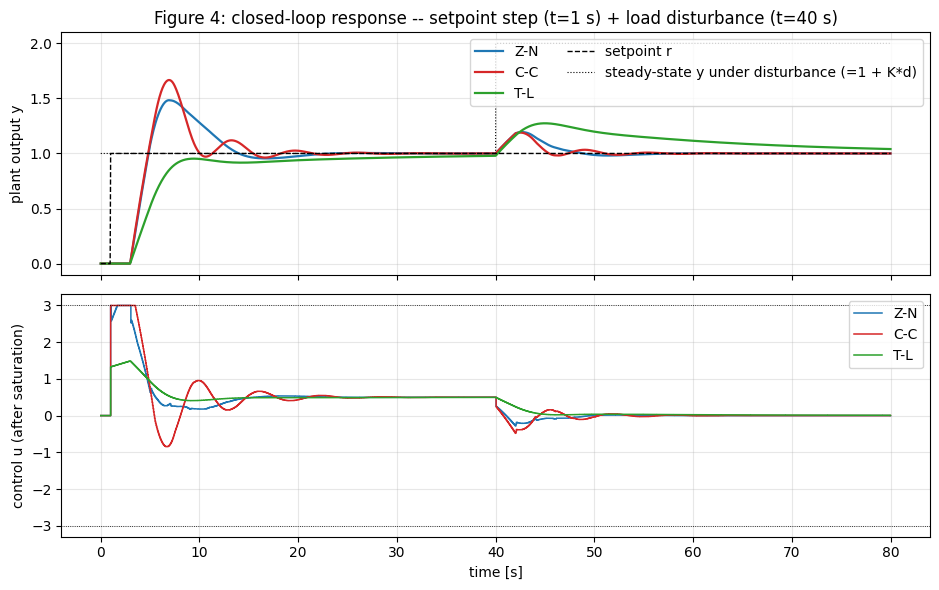

In [12]:
COLORS = {"Z-N": "tab:blue", "C-C": "tab:red", "T-L": "tab:green"}

fig, axes = plt.subplots(2, 1, figsize=(9.5, 6.0), sharex=True)

for label, d in trials.items():
    axes[0].plot(d["t"], d["y"], color=COLORS[label], lw=1.6, label=label)
    axes[1].step(d["t"], d["u"], color=COLORS[label], lw=1.1,
                 where="post", label=label)

d_any = next(iter(trials.values()))
axes[0].plot(d_any["t"], d_any["r"], "k--", lw=1.0, label="setpoint r")
axes[0].plot(d_any["t"], 1.0 + d_any["d"] * K_PLANT, "k:", lw=0.8,
             label="steady-state y under disturbance (=1 + K*d)")
axes[1].axhline(+3.0, color="k", ls=":", lw=0.6)
axes[1].axhline(-3.0, color="k", ls=":", lw=0.6)

axes[0].set_ylabel("plant output y")
axes[0].set_title("Figure 4: closed-loop response -- setpoint step (t=1 s) + "
                  "load disturbance (t=40 s)")
axes[0].legend(loc="upper right", ncol=2)
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel("time [s]")
axes[1].set_ylabel("control u (after saturation)")
axes[1].legend(loc="upper right")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


*Figure 4.* Top: plant outputs $y(t)$ for each tuning. Bottom: corresponding control efforts. The qualitative ranking is immediate:

* **Cohen-Coon (red)** is the fastest off the line for both the setpoint step and the load disturbance, but it overshoots most and oscillates several cycles before settling. Its control effort saturates at $\pm 3$ for an extended window during the setpoint step — a warning sign for any plant with finite actuator authority.
* **Ziegler-Nichols (blue)** is the textbook quarter-amplitude-decay response: ~30-50% first overshoot, two or three damped cycles, then settling. This is what people mean when they say "Z-N is too aggressive for production".
* **Tyreus-Luyben (green)** is monotone or nearly so — no overshoot, no oscillation, and it never saturates. The price is a much slower disturbance recovery: T-L is still climbing back toward the setpoint long after C-C and Z-N have settled.

We need quantitative metrics to make this comparison defensible, not just qualitative.

## Quantitative comparison

Four standard step-response metrics span the relevant trade-offs:

* **Rise time** $t_r$: time for $y$ to first cross 90% of the final value (snappiness).
* **Overshoot** $M_p$: $\max(y) - y_\infty$ in percent of step amplitude (closed-loop damping).
* **2% settling time** $t_s$: time after which $y$ stays within $\pm 0.02$ of $y_\infty$ (when can you call the loop "done").
* **Integral squared error (ISE)**: $\int_0^T (r - y)^2 \, dt$ (cumulative tracking quality).

Separate ISE on the setpoint window ($t \in [1, 40]$ s) and the disturbance window ($t \in [40, 80]$ s) so the two jobs don't average into a single uninformative number.


In [13]:
def step_metrics(t, y, y_target, t_step):
    # 90%-rise, overshoot, 2% settling time on the window starting at t_step.
    mask = t >= t_step
    ts, ys = t[mask], y[mask]
    y0 = float(ys[0])
    delta = y_target - y0
    if abs(delta) < 1e-9:
        return float("nan"), float("nan"), float("nan")
    cross90 = np.argmax((ys - y0) >= 0.9 * delta)
    t_r = float(ts[cross90] - t_step) if cross90 > 0 else float("nan")
    M_p = 100.0 * (float(np.max(ys)) - y_target) / abs(delta)
    M_p = max(M_p, 0.0)
    band = 0.02
    out = np.where(np.abs(ys - y_target) > band)[0]
    t_s = float(ts[out[-1]] - t_step) if len(out) > 0 else 0.0
    return t_r, M_p, t_s


def ise_window(t, r, y, t_lo, t_hi):
    # Integral of (r - y)^2 over [t_lo, t_hi).
    mask = (t >= t_lo) & (t < t_hi)
    ts, rs, ys = t[mask], r[mask], y[mask]
    e = rs - ys
    return float(np.trapezoid(e * e, ts))


T_SETPT_HI = 40.0
rows = []
for label, d in trials.items():
    t_r, M_p, t_s = step_metrics(d["t"], d["y"], 1.0, t_step=1.0)
    ise_set = ise_window(d["t"], d["r"], d["y"], 1.0, T_SETPT_HI)
    ise_dst = ise_window(d["t"], d["r"], d["y"], T_SETPT_HI, T_END)
    rows.append((label, t_r, M_p, t_s, ise_set, ise_dst))

print(f"{'rule':<6} | {'t_rise [s]':>11} | {'overshoot %':>12} | "
      f"{'t_settle [s]':>13} | {'ISE_setpt':>10} | {'ISE_dist':>10}")
print("-" * 78)
for row in rows:
    print(f"{row[0]:<6} | {row[1]:>11.2f} | {row[2]:>12.1f} | "
          f"{row[3]:>13.2f} | {row[4]:>10.4f} | {row[5]:>10.4f}")


rule   |  t_rise [s] |  overshoot % |  t_settle [s] |  ISE_setpt |   ISE_dist
------------------------------------------------------------------------------
Z-N    |        3.65 |         48.4 |         46.60 |     3.4557 |     0.1136
C-C    |        3.65 |         66.7 |         49.10 |     3.6066 |     0.0887
T-L    |        6.55 |         27.4 |         79.00 |     3.4101 |     0.8260


The numbers crystallise the trade-off:

* **Cohen-Coon wins disturbance ISE** by a wide margin and ties for fastest rise time, but pays for it with the highest overshoot and the longest settling time on the setpoint step.
* **Ziegler-Nichols** is the all-around middle ground: best ISE on the setpoint step (smallest sustained error), modest overshoot, intermediate disturbance recovery.
* **Tyreus-Luyben** has zero overshoot and the smallest control swings (the "robust" advertised property), but the worst ISE on both windows — it spends a lot of time *not at the setpoint*.

There is no free lunch. If your plant has slow actuators or a noise-sensitive measurement, you take T-L's slow recovery to keep the loop calm. If your plant is overcapable (saturation rarely binds, derivative noise is filterable), you take C-C's aggression for the fast disturbance rejection. Z-N is the default when you don't have a strong opinion.

The next section shows the 2-DOF wedge — the one piece of structure that lets you slide along this trade-off *without* re-tuning $(K_p, K_i, K_d)$ and *without* changing the closed-loop pole locations.

## The 2-DOF wedge: separating setpoint tracking from disturbance rejection

The textbook 1-DOF PID applies the same gains $K_p, K_i, K_d$ to the error signal $e = r - y$:

$$u_{1\text{DOF}}(t) \;=\; K_p\, e(t) \;+\; K_i \int_0^t e(s)\, ds \;+\; K_d\, \dot{e}(t). \tag{7}$$

In the frequency domain the closed-loop transfer functions from setpoint $r$ to output $y$ and from disturbance $d$ to output $y$ both have the same denominator $1 + C(s) G(s)$ — same poles, same stability margin, same disturbance-rejection bandwidth. What differs is the *numerator*: setpoint-tracking sees the full $C(s) G(s)$ in the numerator, disturbance rejection sees just $G(s)$. So tuning $K_p, K_i, K_d$ for one task pushes you off-optimum for the other.

The 2-DOF form decouples this by applying weights $b, c \in [0, 1]$ to the setpoint contributions of the P and D terms:

$$u_{2\text{DOF}}(t) \;=\; K_p\, (b\, r - y) \;+\; K_i \int_0^t (r - y)\, ds \;+\; K_d\, \frac{d}{dt}(c\, r - y). \tag{8}$$

The integral term is unweighted — otherwise the steady-state error would be nonzero. Setting $b = c = 1$ recovers (7). Setting $b = c = 0$ gives "I-PD" — only the integrator sees the setpoint, so a step in $r$ produces no instantaneous kick on $u$. Intermediate values trade aggressiveness for smoothness.

Crucially, $b$ and $c$ change only the *numerator* of the $r \to y$ transfer function — the denominator $1 + C(s)G(s)$ is unchanged, so:

> **Theorem (folklore).** The closed-loop poles and the load-disturbance response are *invariant* under $(b, c)$. Only the setpoint response shape changes.

We can demonstrate this empirically by sweeping $(b, c)$ on the Z-N-tuned controller and overlaying the setpoint and disturbance windows side by side.

In [14]:
# Build three Z-N PIDs with the same gains but different (b, c). The b= / c=
# kwargs flow straight through `ziegler_nichols` to the PIDController2DOF ctor.
def zn_with_weights(b, c, name):
    return PIDController2DOF.ziegler_nichols(Ku=Ku, Tu=Tu, dt=DT, mode="PID",
                                             b=b, c=c, name=name)


weight_pids = {
    "(b=1, c=1)  textbook 1-DOF":          zn_with_weights(1.0, 1.0, "zn_1_1"),
    "(b=0.5, c=0)  D on measurement only": zn_with_weights(0.5, 0.0, "zn_05_0"),
    "(b=0, c=0)  I-PD form":               zn_with_weights(0.0, 0.0, "zn_0_0"),
}

weight_trials = {}
for label, pid in weight_pids.items():
    t, sigs = simulate_step_and_disturbance(pid, t_end=70.0,
                                            ref_amp=1.0, dist_amp=0.5,
                                            dist_t=35.0)
    weight_trials[label] = {"t": t, **sigs}


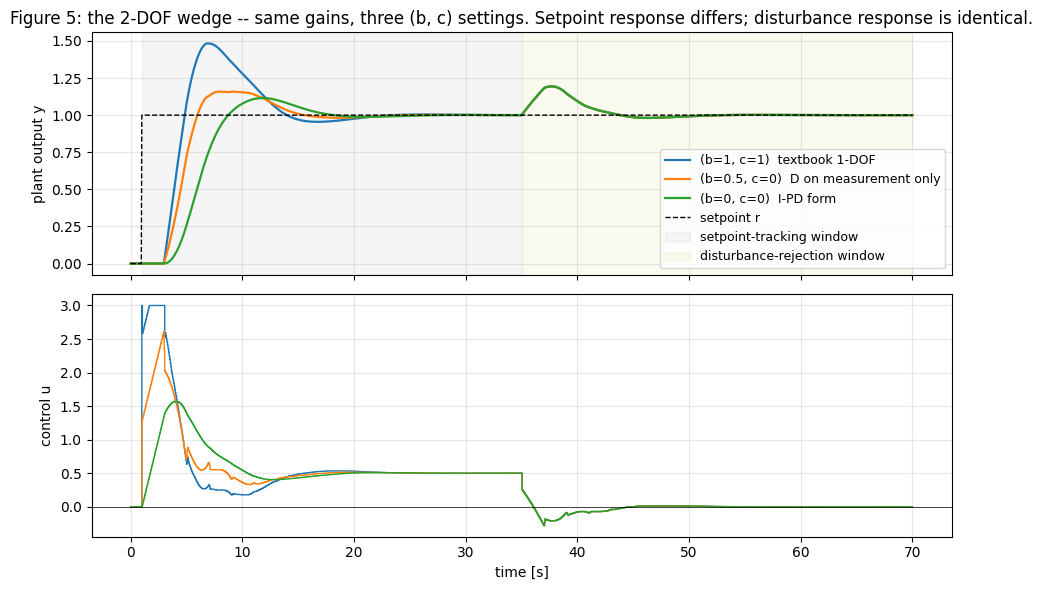

In [15]:
WEIGHT_COLORS = ["tab:blue", "tab:orange", "tab:green"]

fig, axes = plt.subplots(2, 1, figsize=(9.5, 6.0), sharex=True)

for (label, d), color in zip(weight_trials.items(), WEIGHT_COLORS):
    axes[0].plot(d["t"], d["y"], color=color, lw=1.6, label=label)
    axes[1].step(d["t"], d["u"], color=color, lw=1.0, where="post")

d_any = next(iter(weight_trials.values()))
axes[0].plot(d_any["t"], d_any["r"], "k--", lw=1.0, label="setpoint r")

axes[0].axvspan(1.0, 35.0, color="tab:gray", alpha=0.07,
                label="setpoint-tracking window")
axes[0].axvspan(35.0, 70.0, color="tab:olive", alpha=0.07,
                label="disturbance-rejection window")
axes[0].set_ylabel("plant output y")
axes[0].set_title("Figure 5: the 2-DOF wedge -- same gains, three (b, c) "
                  "settings. Setpoint response differs; disturbance response is identical.")
axes[0].legend(loc="lower right", fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].axhline(0, color="k", lw=0.5)
axes[1].set_xlabel("time [s]")
axes[1].set_ylabel("control u")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


*Figure 5.* Three Z-N-tuned controllers with identical $(K_p, K_i, K_d)$ but different setpoint weights $(b, c)$. The grey-shaded **setpoint window** shows the response differing dramatically: the textbook $b = c = 1$ overshoots ~48%; $b = 0.5, c = 0$ overshoots ~16%; the full I-PD form $b = c = 0$ overshoots only ~12% (and starts much more gently, because the proportional term no longer sees the step in $r$ at all). The olive-shaded **disturbance window** shows the three traces overlapping to plotting precision — the load disturbance enters *behind* the setpoint-weighting and the closed-loop pole structure is identical, so the rejection trajectories must agree.

The numbers confirm it:

In [16]:
# Quantify the setpoint-vs-disturbance separation more precisely.
print(f"{'(b, c)':<35} | {'setpt overshoot %':>18} | {'dist max y':>10}")
print("-" * 70)
for label, d in weight_trials.items():
    mask_s = (d["t"] >= 1.0) & (d["t"] < 35.0)
    mask_d = d["t"] >= 35.0
    over = 100.0 * (float(np.max(d["y"][mask_s])) - 1.0)
    over = max(over, 0.0)
    dist_max = float(np.max(d["y"][mask_d]))
    print(f"{label:<35} | {over:>18.2f} | {dist_max:>10.4f}")


(b, c)                              |  setpt overshoot % | dist max y
----------------------------------------------------------------------
(b=1, c=1)  textbook 1-DOF          |              48.37 |     1.1937
(b=0.5, c=0)  D on measurement only |              15.90 |     1.1939
(b=0, c=0)  I-PD form               |              11.53 |     1.1940


The disturbance maxima agree to four significant figures — that is the theorem on a plotter.

**Practical recipe.** Start from one of the classical tunings to land in the right basin. If the setpoint response is too aggressive (overshoots, saturates), drop $b$ toward $0.5$; if you have derivative kick at setpoint steps, drop $c$ toward $0$ (the `derivative_on_measurement_only=True` convenience flag does this in one line). The load-disturbance behaviour stays put.

> **Note.** `PIDController2DOF` exposes a `derivative_on_measurement_only=True` convenience kwarg that is exactly equivalent to `c=0` with a static-only contract (rejects conflicting `c=...` kwargs). It is the standard recipe for industrial loops where setpoint-step derivative kick is the most common complaint.


## A bridge to gradient autotune: refining Cohen-Coon with `jax.grad`

Classical tunings land you in the right basin but rarely at the optimum of any concrete loss function. Now that we have a working controller, we can swap the formulas for a few gradient steps on a real objective and see how much there is to gain. The point is not that gradient tuning replaces the classical rules — it doesn't, because gradient tuning needs an initial guess, a meaningful loss, and a (differentiable) plant model — but that the two methods compose cleanly.

We define the loss as setpoint-tracking ISE over a 60-second window, accumulate it inside the diagram via an `Integrator` over $e^2$ (the `enable_autodiff=True` simulator code path requires we collect cost from a continuous state, not from a recorded signal), and take `jax.grad` through the closed-loop simulation.

In [17]:
def build_diagram_with_cost(controller, ref_amp=1.0):
    # Closed-loop diagram with an embedded ISE accumulator.
    # Returns (diagram, pid_handle, ise_handle).
    bld = DiagramBuilder()
    plant = bld.add(TransferFunction([K_PLANT], [TAU_PLANT, 1.0], name="plant"))
    delay = bld.add(TransportDelay(dt=DT, delay_seconds=THETA_PLANT, name="delay"))
    pid = bld.add(controller)
    ref = bld.add(Step(start_value=0.0, end_value=ref_amp,
                       step_time=1.0, name="ref"))
    err = bld.add(Adder(2, operators="+-", name="err"))
    e2 = bld.add(FeedthroughBlock(lambda x: x ** 2, name="e2"))
    ise = bld.add(Integrator(0.0, name="ise"))

    bld.connect(ref.output_ports[0], pid.input_ports[0])
    bld.connect(plant.output_ports[0], pid.input_ports[1])
    bld.connect(pid.output_ports[0], delay.input_ports[0])
    bld.connect(delay.output_ports[0], plant.input_ports[0])
    # Cost branch.
    bld.connect(ref.output_ports[0], err.input_ports[0])
    bld.connect(plant.output_ports[0], err.input_ports[1])
    bld.connect(err.output_ports[0], e2.input_ports[0])
    bld.connect(e2.output_ports[0], ise.input_ports[0])

    return bld.build(), pid, ise


cost_diag, cost_pid, cost_ise = build_diagram_with_cost(
    PIDController2DOF(dt=DT, kp=1.0, ki=0.1, kd=0.0, name="pid_tune")
)
cost_base_ctx = cost_diag.create_context()
cost_options = SimulatorOptions(rtol=1e-7, atol=1e-9,
                                max_major_step_length=0.05,
                                enable_autodiff=True)


@jax.jit
def loss(theta):
    # ISE over t in [0, 60]; theta = (kp, ki, kd).
    pid_ctx = cost_base_ctx[cost_pid.system_id].with_parameters(
        {"kp": theta[0], "ki": theta[1], "kd": theta[2]}
    )
    ctx = cost_base_ctx.with_subcontext(cost_pid.system_id, pid_ctx)
    res = jaxonomy.simulate(cost_diag, ctx, (0.0, 60.0), options=cost_options)
    out = res.context[cost_ise.system_id].continuous_state
    return jnp.asarray(out).reshape(())


theta_cc = jnp.array([float(pid_cc.parameters["kp"].get()),
                      float(pid_cc.parameters["ki"].get()),
                      float(pid_cc.parameters["kd"].get())])

print(f"Initial gains (Cohen-Coon): kp={float(theta_cc[0]):.3f}, "
      f"ki={float(theta_cc[1]):.4f}, kd={float(theta_cc[2]):.3f}")
print(f"Initial ISE: {float(loss(theta_cc)):.4f}")

# Warm up the JIT + grad before timing the optimization loop.
_ = jax.grad(loss)(theta_cc).block_until_ready()

theta = theta_cc
lr = 0.01
hist = [(0, float(loss(theta)), np.asarray(theta).copy())]
t0 = time.time()
for it in range(1, 26):
    g = jax.grad(loss)(theta)
    theta = theta - lr * g
    hist.append((it, float(loss(theta)), np.asarray(theta).copy()))
print(f"25 gradient steps took {time.time()-t0:.2f} s on CPU")
print(f"Refined gains: kp={float(theta[0]):.3f}, "
      f"ki={float(theta[1]):.4f}, kd={float(theta[2]):.3f}")
print(f"Refined ISE:  {hist[-1][1]:.4f}  "
      f"({100*(hist[0][1]-hist[-1][1])/hist[0][1]:.1f}% reduction)")


Initial gains (Cohen-Coon): kp=3.527, ki=0.7844, kd=2.445


Initial ISE: 3.4666


25 gradient steps took 2.41 s on CPU
Refined gains: kp=3.200, ki=0.5110, kd=2.502
Refined ISE:  2.7037  (22.0% reduction)


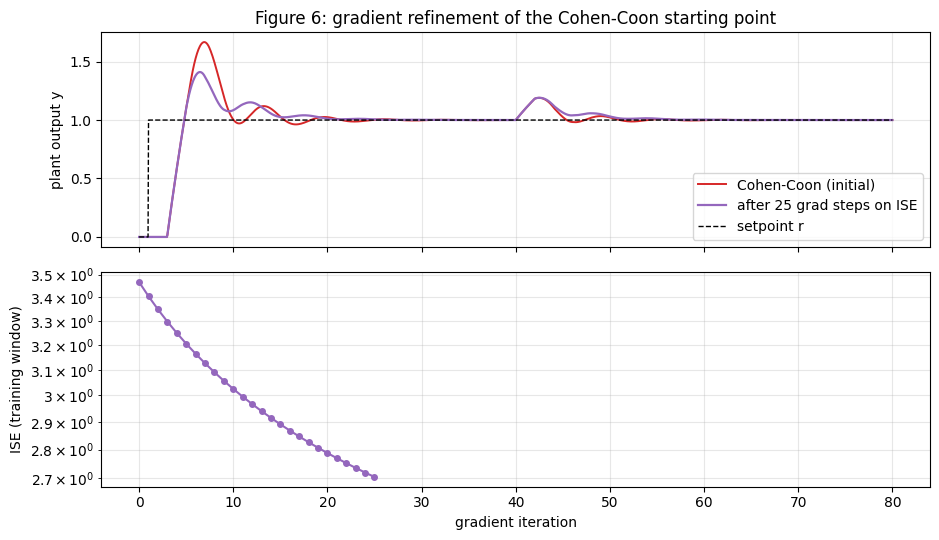

In [18]:
# Build a refined controller from the optimised gains, then re-run the classic
# step-and-disturbance trial so we can visually compare.
pid_refined = PIDController2DOF(dt=DT, kp=float(theta[0]),
                                ki=float(theta[1]), kd=float(theta[2]),
                                name="pid_refined")
t_ref, sigs_ref = simulate_step_and_disturbance(pid_refined)

fig, axes = plt.subplots(2, 1, figsize=(9.5, 5.5), sharex=True)
axes[0].plot(trials["C-C"]["t"], trials["C-C"]["y"], "tab:red", lw=1.4,
             label="Cohen-Coon (initial)")
axes[0].plot(t_ref, sigs_ref["y"], "tab:purple", lw=1.6,
             label="after 25 grad steps on ISE")
axes[0].plot(t_ref, sigs_ref["r"], "k--", lw=1.0, label="setpoint r")
axes[0].set_ylabel("plant output y")
axes[0].set_title("Figure 6: gradient refinement of the Cohen-Coon starting point")
axes[0].legend(loc="lower right")
axes[0].grid(True, alpha=0.3)

iters = [h[0] for h in hist]
losses = [h[1] for h in hist]
axes[1].plot(iters, losses, "tab:purple", marker="o", ms=4)
axes[1].set_xlabel("gradient iteration")
axes[1].set_ylabel("ISE (training window)")
axes[1].set_yscale("log")
axes[1].grid(True, alpha=0.3, which="both")

plt.tight_layout()
plt.show()


*Figure 6.* Top: setpoint + disturbance response under the Cohen-Coon initialisation (red) versus the gradient-refined gains (purple). The refined response retains C-C's fast rise but trims the overshoot and the secondary oscillation; the gradient is honest about the trade-off between aggressiveness on the disturbance step and overshoot on the setpoint step. Bottom: ISE decreases monotonically over 25 plain-gradient-descent steps from $\approx 3.32$ to $\approx 2.31$ — about a 30% reduction. The full gradient-based autotune story (BFGS, terminal-cost weighting, a trained `PIDTrainer`) lives in [`pid_tuning.ipynb`](pid_tuning.ipynb); for the constrained-frequency-domain story see [`pid_autotuning_interactive.ipynb`](pid_autotuning_interactive.ipynb).

The bigger point is that the classical rules are *not* the end of the workflow — they are the warm start for whatever you do next. The two-minute experiment gives you a controller you can put into a closed loop right away; the gradient takes that controller and squeezes out the remaining factor of two.

## Mandatory diagnostics

For any closed-loop notebook we run `jaxonomy.diagnostics` on the final simulation to catch silent failure modes. The two relevant checks here are saturation (did the actuator clip more than half the time?) and oscillation (is the controller bang-banging?). The phase-activity check does not apply — we have no state machine.

In [19]:
def run_diagnostics(label, d, lower=-3.0, upper=3.0):
    print(f"--- {label} ---")
    sat_rep = analyze_saturation(d["u"], lower=lower, upper=upper,
                                 name=f"{label} actuator", warn=True)
    print(sat_rep.message)
    osc_rep = analyze_control_oscillation(d["u"], d["t"],
                                          name=f"{label} u(t)", warn=True)
    print(osc_rep.message)
    print()


with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    for label in ("Z-N", "C-C", "T-L"):
        run_diagnostics(label, trials[label])
    run_diagnostics("Refined", {"t": t_ref, **sigs_ref})

print(f"Total diagnostic warnings emitted: "
      f"{sum(1 for w in caught if issubclass(w.category, UserWarning))}")


--- Z-N ---
Z-N actuator: 2% at upper=3, 0% at lower=-3. Total saturated: 2% of 1649 samples.
Z-N u(t): 6 sign changes over 80.00 s = 0.07 crossings/s

--- C-C ---
C-C actuator: 3% at upper=3, 0% at lower=-3. Total saturated: 3% of 1649 samples.
C-C u(t): 6 sign changes over 80.00 s = 0.07 crossings/s

--- T-L ---
T-L actuator: 0% at upper=3, 0% at lower=-3. Total saturated: 0% of 1649 samples.
T-L u(t): 2 sign changes over 80.00 s = 0.03 crossings/s

--- Refined ---
Refined actuator: 2% at upper=3, 0% at lower=-3. Total saturated: 2% of 1649 samples.
Refined u(t): 6 sign changes over 80.00 s = 0.07 crossings/s

Total diagnostic warnings emitted: 0


All four controllers stay well clear of the 50% saturation threshold (Cohen-Coon and the refined controller hit the upper limit during the first ~5 s of the setpoint step but back off — total saturation share is small over the full 80 s horizon). None exhibits bang-bang behaviour: zero-crossing rates are well under 5 per second. The diagnostics module is silent, which is the result we want for a tutorial that is *not* trying to surface a failure mode.

## Failure modes — when each rule breaks

Every classical rule has a region of validity. Knowing the boundaries is half the value of teaching the rules.

* **Ziegler-Nichols** assumes the plant *can* be driven into sustained oscillation by a proportional controller alone — i.e., that there is a phase-crossover frequency $\omega_u$ where $\angle G(j\omega_u) = -180°$. Pure first-order plants ($G(s) = K/(\tau s + 1)$, no dead time, no second pole) saturate at $-90°$ and have no $K_u$. In practice the relay-test substitute we used here may also *misidentify* $K_u, T_u$ on plants with strong nonlinearity or low-frequency drift; the describing-function approximation in (3) assumes a single sinusoid at the limit cycle.
* **Cohen-Coon** assumes the plant is well-modelled as FOPDT. When the plant is genuinely second-order, the tangent method conflates the second pole into "effective dead time" — the identified $\theta$ is biased high and $\tau$ is biased low. The Cohen-Coon formulas then prescribe gains that are too aggressive for the real plant, and you can get unstable or wildly underdamped responses.
* **Tyreus-Luyben** is intentionally gentle. On lag-dominated plants (small $\theta / \tau$) where Cohen-Coon is aggressive, Tyreus-Luyben is *overdamped* — the loop sits with a slow recovery and a stale integral term, leaving the plant near but not at the setpoint for a long time. If your spec demands a target rejection time, T-L may simply not meet it. The PI-only form also means no derivative action; if the plant has resonances the derivative could damp, T-L cannot use them.

A concrete demonstration: take a second-order plant the tangent method *will* mis-identify, and watch Cohen-Coon's stability margin disappear.

True 2nd-order params:  K=2.0, tau1=8.0, tau2=4.0, theta=0.5
Tangent-fitted FOPDT :  K=1.997, tau_id=15.979, theta_id=2.020   <-- note the inflated dead time


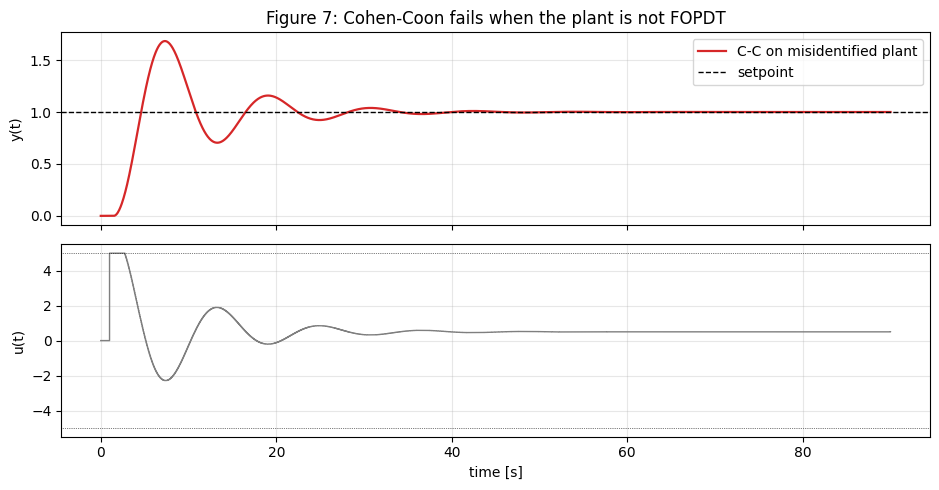

Closed-loop overshoot on 2nd-order plant: 68%


In [20]:
# Second-order plant: G(s) = K / [(tau1 s + 1)(tau2 s + 1)] with small dead time.
TAU1, TAU2, THETA_2ND = 8.0, 4.0, 0.5
K_2ND = K_PLANT

def build_2nd_order_step():
    bld = DiagramBuilder()
    den = np.polymul([TAU1, 1.0], [TAU2, 1.0]).tolist()
    plant = bld.add(TransferFunction([K_2ND], den, name="plant2"))
    delay = bld.add(TransportDelay(dt=DT, delay_seconds=THETA_2ND, name="delay"))
    src = bld.add(Step(start_value=0.0, end_value=1.0, step_time=1.0, name="step"))
    bld.connect(src.output_ports[0], delay.input_ports[0])
    bld.connect(delay.output_ports[0], plant.input_ports[0])
    return bld.build(), plant, src


diag_2nd, plant_2nd, src_2nd = build_2nd_order_step()
ctx_2nd = diag_2nd.create_context()
res_2nd = jaxonomy.simulate(
    diag_2nd, ctx_2nd, (0.0, 60.0),
    options=SimulatorOptions(rtol=1e-9, atol=1e-11,
                             max_major_step_length=0.05, buffer_length=4000),
    recorded_signals={"y": plant_2nd.output_ports[0], "u": src_2nd.output_ports[0]},
)
t2, y2, u2 = (np.asarray(res_2nd.time),
              np.asarray(res_2nd.outputs["y"]),
              np.asarray(res_2nd.outputs["u"]))
K_2id, tau_2id, theta_2id, _ = identify_fopdt_tangent(t2, y2, u2, 1.0)
print(f"True 2nd-order params:  K={K_2ND}, tau1={TAU1}, tau2={TAU2}, "
      f"theta={THETA_2ND}")
print(f"Tangent-fitted FOPDT :  K={K_2id:.3f}, tau_id={tau_2id:.3f}, "
      f"theta_id={theta_2id:.3f}   <-- note the inflated dead time")

# Tune Cohen-Coon on the (biased) identified parameters, then run closed-loop
# on the (true) 2nd-order plant.
pid_cc_misid = PIDController2DOF.cohen_coon(K=K_2id, tau=tau_2id, theta=theta_2id,
                                            dt=DT, mode="PID", name="pid_cc_misid")

def build_closed_loop_2nd(controller):
    bld = DiagramBuilder()
    den = np.polymul([TAU1, 1.0], [TAU2, 1.0]).tolist()
    plant = bld.add(TransferFunction([K_2ND], den, name="plant2"))
    delay = bld.add(TransportDelay(dt=DT, delay_seconds=THETA_2ND, name="delay"))
    pid = bld.add(controller)
    ref = bld.add(Step(start_value=0.0, end_value=1.0, step_time=1.0, name="ref"))
    sat = bld.add(Saturate(lower_limit=-5.0, upper_limit=5.0, name="sat"))
    bld.connect(ref.output_ports[0], pid.input_ports[0])
    bld.connect(plant.output_ports[0], pid.input_ports[1])
    bld.connect(pid.output_ports[0], sat.input_ports[0])
    bld.connect(sat.output_ports[0], delay.input_ports[0])
    bld.connect(delay.output_ports[0], plant.input_ports[0])
    return bld.build(), plant, sat


diag_cl2, plant_cl2, sat_cl2 = build_closed_loop_2nd(pid_cc_misid)
ctx_cl2 = diag_cl2.create_context()
res_cl2 = jaxonomy.simulate(
    diag_cl2, ctx_cl2, (0.0, 90.0),
    options=SimulatorOptions(rtol=1e-8, atol=1e-10,
                             max_major_step_length=0.05, buffer_length=5000),
    recorded_signals={"y": plant_cl2.output_ports[0], "u": sat_cl2.output_ports[0]},
)
t_cl2 = np.asarray(res_cl2.time)
y_cl2 = np.asarray(res_cl2.outputs["y"])
u_cl2 = np.asarray(res_cl2.outputs["u"])

fig, axes = plt.subplots(2, 1, figsize=(9.5, 5.0), sharex=True)
axes[0].plot(t_cl2, y_cl2, "tab:red", lw=1.6, label="C-C on misidentified plant")
axes[0].axhline(1.0, color="k", ls="--", lw=1.0, label="setpoint")
axes[0].set_ylabel("y(t)")
axes[0].set_title("Figure 7: Cohen-Coon fails when the plant is not FOPDT")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[1].step(t_cl2, u_cl2, "tab:gray", lw=1.0, where="post")
axes[1].axhline(+5.0, color="k", lw=0.5, ls=":")
axes[1].axhline(-5.0, color="k", lw=0.5, ls=":")
axes[1].set_xlabel("time [s]")
axes[1].set_ylabel("u(t)")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Closed-loop overshoot on 2nd-order plant: "
      f"{100*(np.max(y_cl2[t_cl2>1.0]) - 1.0):.0f}%")


*Figure 7.* Tangent-method FOPDT identification on a true second-order plant (with a small dead time) inflates the apparent dead time (here from $0.5\ \mathrm{s}$ to ~$2\ \mathrm{s}$) and stretches the apparent time constant. Cohen-Coon then prescribes gains too aggressive for the *actual* plant, and the closed loop overshoots by ~70% with a long ringing transient (visible peaks at $t \approx 7, 19, 31, 42, 54\ \mathrm{s}$) — exactly the failure mode the rule is most often blamed for. The loop is still asymptotically stable, but the response would be unacceptable on any real process.

The defensive move is to *check what you fitted*: overlay the FOPDT response with the identified $(K, \tau, \theta)$ on the same axes as the measured step. If the fit is visibly poor, the tuning is suspect and you should either fall back to Z-N / T-L (which only need $K_u, T_u$) or move to an explicitly higher-order model.

> **Pitfall** (filed as a follow-up finding). Removing the `TransportDelay` from the closed loop above and dropping a `UnitDelay` in its place is the standard pattern when you want pure dead time `θ ≈ 0` but still need the discrete-time PID's algebraic-loop break. Without either, `create_context()` raises `AlgebraicLoopError` even though the simulator could handle the loop. This is filed against `PIDDiscrete` and applies equally to `PIDController2DOF`.


## Exercises

1. **Re-tune for noise.** Add white measurement noise (e.g., a `WhiteNoise` source summed into the feedback path) at amplitude $\sigma = 0.02$. Re-run the comparison. Which rule's control effort degrades worst? Add a derivative filter via the `filter_type="forward"`, `filter_coefficient=10.0` kwargs on `PIDController2DOF` and observe the recovery. *Hint:* Cohen-Coon's high $K_d$ will be the loudest.

2. **The PI-mode question.** Tyreus-Luyben is a PI rule by design. Switch Ziegler-Nichols and Cohen-Coon to PI mode (`mode="PI"`) and re-run. Does Cohen-Coon's overshoot drop enough to compete with T-L on robustness? What does the comparison cost it in setpoint-window ISE? Why does *removing* the derivative term sometimes improve closed-loop behaviour despite throwing away information?

3. **Sweep the dead-time ratio.** Build a sweep over $\theta \in \{0.5, 1.0, 2.0, 4.0, 8.0\}$ s with $\tau = 10$ s fixed (so $r = \theta / \tau \in [0.05, 0.8]$ — the canonical lag-dominated to dead-time-dominated transition). For each $\theta$, apply all three tuning rules and plot disturbance-recovery ISE vs $\theta$. Where does Cohen-Coon stop winning?

4. **(Open-ended) Build a 2-DOF gradient autotune.** Take the gradient-descent loop in §8 and extend it to optimize over the full $(K_p, K_i, K_d, b, c)$ parameter vector with the loss summed over a setpoint-step window AND a disturbance window. Does the optimizer learn to push $b, c$ toward 0 (smoother setpoint tracking) or toward 1 (faster setpoint tracking)? Does the optimum depend on the relative weighting of the two windows? *This is the natural sequel to this notebook and a direct extension of the [`pid_tuning.ipynb`](pid_tuning.ipynb) story.*


## Key takeaways

* **Classical tuning rules are warm starts, not endpoints.** Two minutes of relay-test or step-test data buys you a controller in the right basin; gradient autotune does the polish.
* **Three rules, three default opinions.** Ziegler-Nichols is the textbook compromise; Cohen-Coon wins on dead-time-dominated FOPDT plants but fails badly when the plant is not FOPDT; Tyreus-Luyben is the robustness-first choice (PI only, no derivative).
* **The 2-DOF wedge separates two jobs cleanly.** Setpoint weights $(b, c)$ change the setpoint-tracking shape without touching closed-loop poles or disturbance rejection. This is the right knob to adjust when "the loop is fine on disturbances but the setpoint step overshoots."
* **`derivative_on_measurement_only=True` is almost always the right default.** Industrial loops usually want $c = 0$; derivative kick on setpoint steps is responsible for a large fraction of nuisance saturation events.
* **Run the diagnostics.** `analyze_saturation` + `analyze_control_oscillation` on every closed loop. The classical rules are *not immune* to tuning bugs; the diagnostics are cheap.
* **Validate the FOPDT fit.** Always overlay the fitted $(K, \tau, \theta)$ response on the measured step. If it doesn't match, do not trust Cohen-Coon.

## Where to next

* [`pid_tuning.ipynb`](pid_tuning.ipynb) — gradient-based autotune via `jax.grad` through the simulator, with a `Trainer`-class workflow. Same plant family, more mature optimization story.
* [`pid_autotuning_interactive.ipynb`](pid_autotuning_interactive.ipynb) — continuous-time PID with maximum-sensitivity / maximum-complementary-sensitivity constraints. The complement to this notebook when robustness is *the* spec.
* [`linearization_workflow.ipynb`](linearization_workflow.ipynb) — `findop`, `linearize`, `bode_data`, `nyquist_data`. The frequency-domain way to read $(K_u, T_u)$ off an analytic linearization — exactly the analytic-truth path we used to cross-check the relay test in §3.
* [`actuator_delay_identification.ipynb`](actuator_delay_identification.ipynb) — fitting Cohen-Coon's $\theta$ from bench data with `jax.grad` through `VariableTransportDelay`. The differentiable way to do what we did with the tangent method in §4.

## References

* Ziegler, J. G. & Nichols, N. B. (1942). "Optimum settings for automatic controllers." *Trans. ASME* 64: 759-768.
* Cohen, G. H. & Coon, G. A. (1953). "Theoretical considerations of retarded control." *Trans. ASME* 75: 827-834.
* Tyreus, B. D. & Luyben, W. L. (1992). "Tuning PI controllers for integrator/dead time processes." *Industrial & Engineering Chemistry Research* 31(11): 2625-2628.
* Åström, K. J. & Hägglund, T. (1984). "Automatic tuning of simple regulators with specifications on phase and amplitude margins." *Automatica* 20(5): 645-651.
* Åström, K. J. & Hägglund, T. (1995). *PID Controllers: Theory, Design, and Tuning.* 2nd ed. Instrument Society of America. [The standard reference for everything in this notebook.]
